In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the synthetic hospital operations dataset

data_path = "../data/hospital_operations.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (2924, 9)


,date,hospital_id,department,admissions,discharges,available_beds,occupied_beds,staff_count,procedure_count
0,2024-01-01,HOSP_001,Emergency,55,38,72,68,44,12
1,2024-01-01,HOSP_001,Medical,40,39,96,70,34,16
2,2024-01-01,HOSP_001,Surgical,28,24,68,52,30,28
3,2024-01-01,HOSP_001,Pediatrics,25,21,52,41,23,9
4,2024-01-02,HOSP_001,Emergency,59,41,72,72,41,11


In [4]:
# Inspect dataset structure and data quality

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['date', 'hospital_id', 'department', 'admissions', 'discharges', 'available_beds', 'occupied_beds', 'staff_count', 'procedure_count']

Data types:
date                 str
hospital_id          str
department           str
admissions         int64
discharges         int64
available_beds     int64
occupied_beds      int64
staff_count        int64
procedure_count    int64
dtype: object

Missing values:
date               0
hospital_id        0
department         0
admissions         0
discharges         0
available_beds     0
occupied_beds      0
staff_count        0
procedure_count    0
dtype: int64

Duplicate rows: 0


In [5]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values(["date", "hospital_id", "department"]).reset_index(drop=True)

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Number of hospitals:", df["hospital_id"].nunique())
print("Departments:", df["department"].unique())

# Descriptive statistics
df.describe()

Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00
Number of hospitals: 1
Departments: <StringArray>
['Emergency', 'Medical', 'Pediatrics', 'Surgical']
Length: 4, dtype: str


,date,admissions,discharges,available_beds,occupied_beds,staff_count,procedure_count
count,2924,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000
mean,2024-12-31 00:00:00,31.259576,29.176813,72.000000,58.094049,33.791724,12.686731
min,2024-01-01 00:00:00,8.000000,7.000000,52.000000,21.000000,18.000000,0.000000
25%,2024-07-01 00:00:00,21.000000,21.000000,64.000000,47.000000,28.000000,8.000000
50%,2024-12-31 00:00:00,27.000000,28.000000,70.000000,61.000000,34.000000,11.000000
75%,2025-07-02 00:00:00,40.000000,38.000000,78.000000,72.000000,39.000000,16.000000
max,2025-12-31 00:00:00,71.000000,56.000000,96.000000,87.000000,50.000000,33.000000
std,NaN,12.541003,9.418531,15.750709,13.448259,6.865607,6.995210


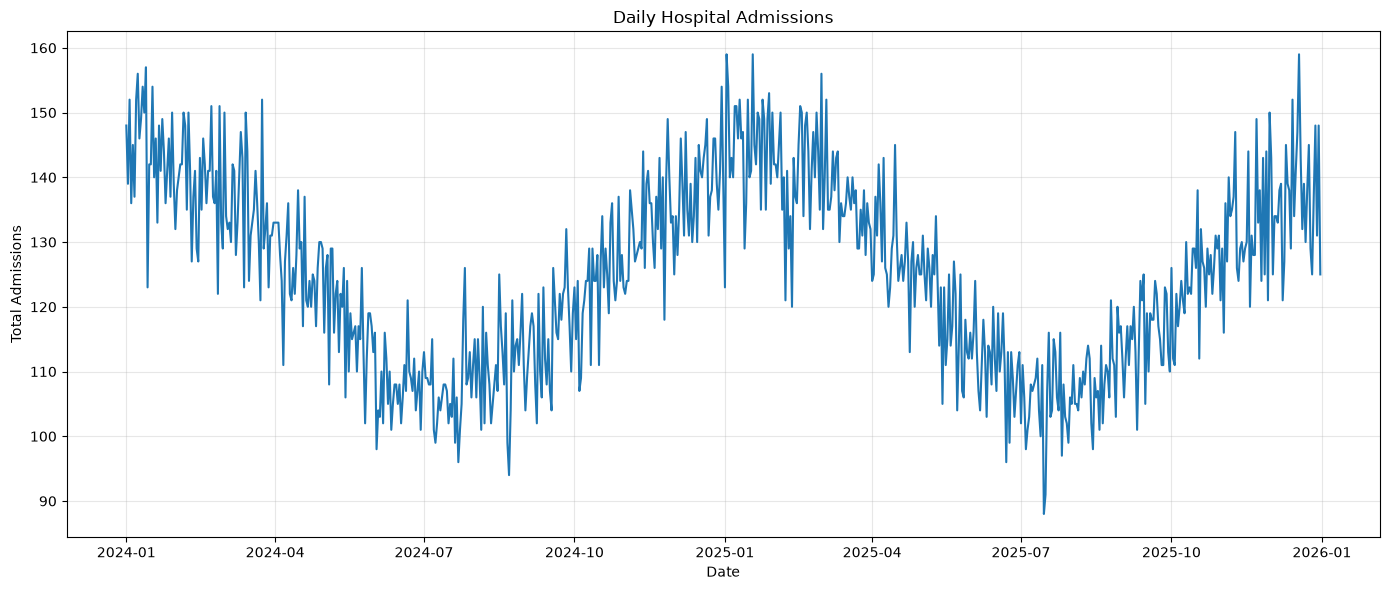

In [6]:
# Aggregate admissions by date
daily_admissions = (
    df.groupby("date", as_index=False)["admissions"]
      .sum()
)

# Plot daily hospital admissions
plt.figure(figsize=(14, 6))
plt.plot(daily_admissions["date"], daily_admissions["admissions"])

plt.title("Daily Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Total Admissions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Average daily admissions by department:
department
Emergency     49.279070
Medical       33.058824
Surgical      22.306430
Pediatrics    20.393981
Name: admissions, dtype: float64


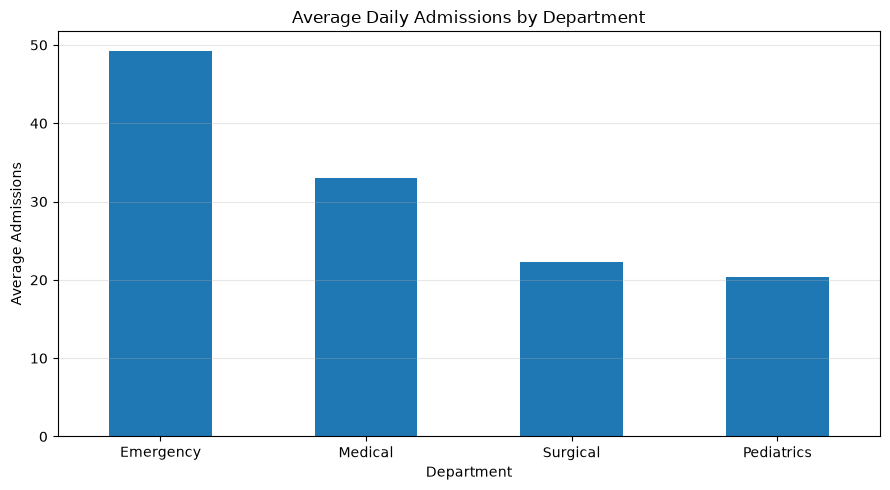

In [7]:
# Calculate average daily admissions by department

department_admissions = (
    df.groupby("department")["admissions"]
      .mean()
      .sort_values(ascending=False)
)

print("Average daily admissions by department:")
print(department_admissions)

# Plot average admissions by department
plt.figure(figsize=(9, 5))
department_admissions.plot(kind="bar")

plt.title("Average Daily Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Average Admissions")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Average bed utilization by department:
department
Emergency     99.71
Surgical      83.68
Pediatrics    75.97
Medical       66.85
Name: bed_utilization, dtype: float64


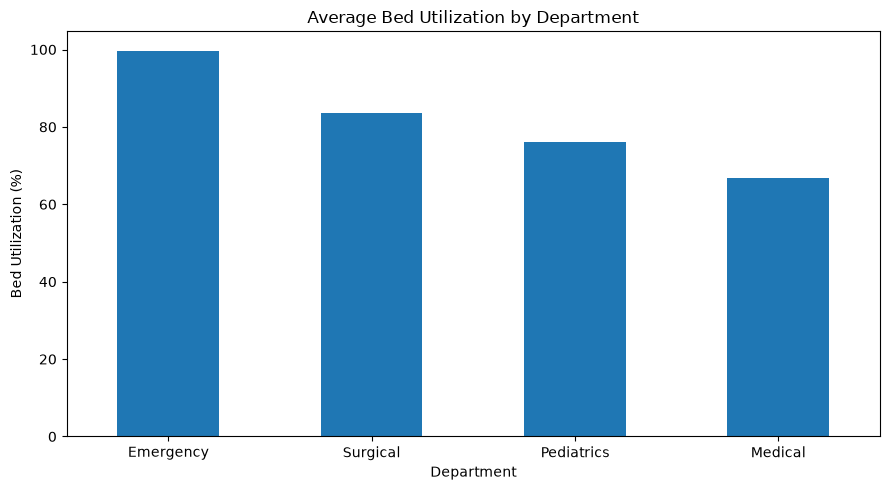

In [8]:
# Calculate bed utilization percentage
df["bed_utilization"] = (
    df["occupied_beds"] / df["available_beds"] * 100
)

# Average bed utilization by department
department_utilization = (
    df.groupby("department")["bed_utilization"]
      .mean()
      .sort_values(ascending=False)
)

print("Average bed utilization by department:")
print(department_utilization.round(2))

# Plot
plt.figure(figsize=(9, 5))
department_utilization.plot(kind="bar")

plt.title("Average Bed Utilization by Department")
plt.xlabel("Department")
plt.ylabel("Bed Utilization (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average staff count by department:
department
Emergency     42.61
Medical       36.54
Surgical      31.02
Pediatrics    24.99
Name: staff_count, dtype: float64


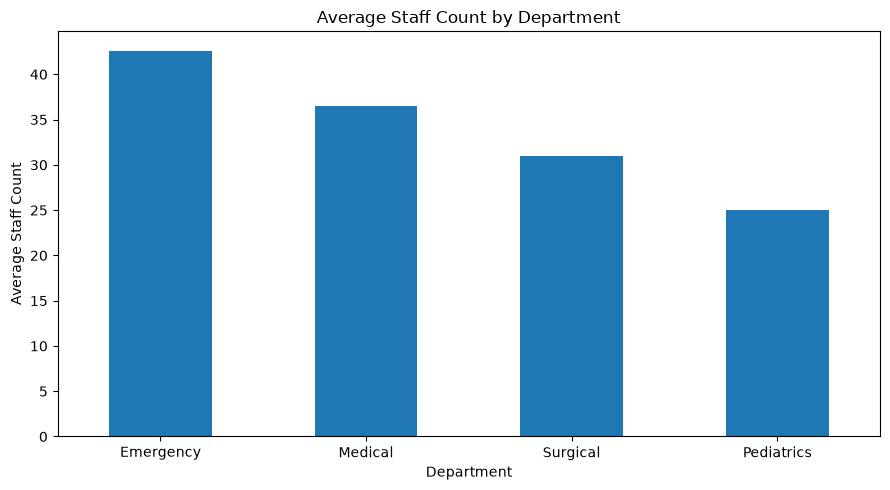

In [9]:
# Calculate average staff count by department
department_staff = (
    df.groupby("department")["staff_count"]
      .mean()
      .sort_values(ascending=False)
)

print("Average staff count by department:")
print(department_staff.round(2))

# Plot average staff count
plt.figure(figsize=(9, 5))
department_staff.plot(kind="bar")

plt.title("Average Staff Count by Department")
plt.xlabel("Department")
plt.ylabel("Average Staff Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average daily procedures by department:
department
Surgical      21.76
Medical       13.19
Emergency      8.84
Pediatrics     6.96
Name: procedure_count, dtype: float64


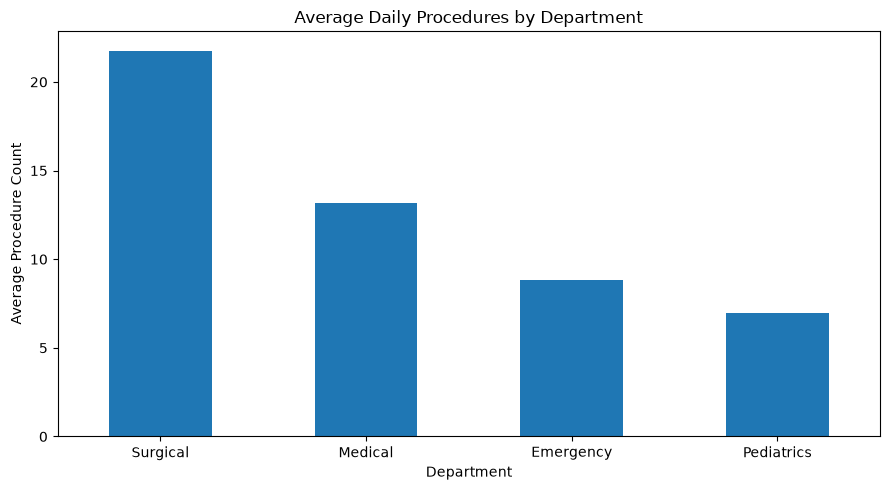

In [10]:
# Calculate average daily procedures by department
department_procedures = (
    df.groupby("department")["procedure_count"]
      .mean()
      .sort_values(ascending=False)
)

print("Average daily procedures by department:")
print(department_procedures.round(2))

# Plot
plt.figure(figsize=(9, 5))
department_procedures.plot(kind="bar")

plt.title("Average Daily Procedures by Department")
plt.xlabel("Department")
plt.ylabel("Average Procedure Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation between admissions and staff count:
0.858


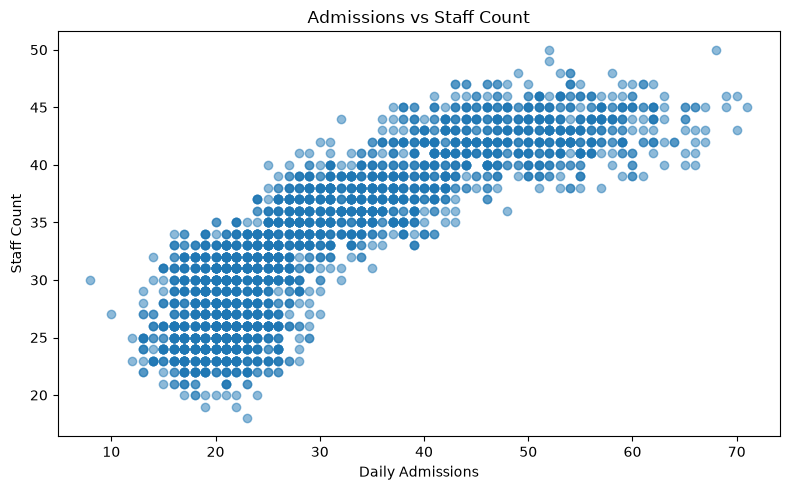

In [11]:
# Analyze relationship between admissions and staff count

correlation = df["admissions"].corr(df["staff_count"])

print("Correlation between admissions and staff count:")
print(round(correlation, 3))

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df["admissions"],
    df["staff_count"],
    alpha=0.5
)

plt.title("Admissions vs Staff Count")
plt.xlabel("Daily Admissions")
plt.ylabel("Staff Count")
plt.tight_layout()
plt.show()

Average daily admissions by month:
month
1     36.14
2     34.89
3     34.00
4     31.85
5     29.63
6     27.33
7     26.54
8     27.46
9     28.85
10    30.96
11    33.18
12    34.45
Name: admissions, dtype: float64


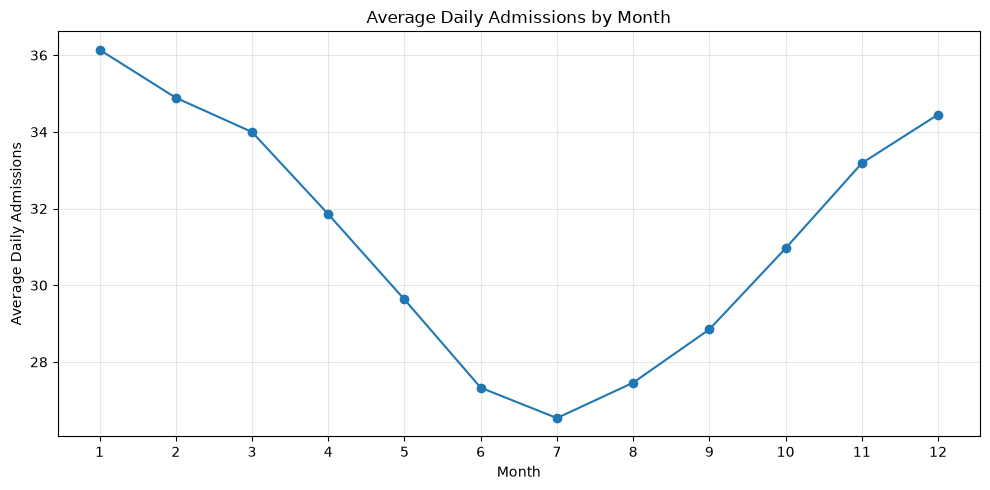

In [12]:
# Extract month from the date
df["month"] = df["date"].dt.month

# Calculate average admissions by month
monthly_admissions = (
    df.groupby("month")["admissions"]
      .mean()
)

print("Average daily admissions by month:")
print(monthly_admissions.round(2))

# Plot monthly admissions
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker="o"
)

plt.title("Average Daily Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Admissions")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Average monthly admissions by department:
department  Emergency  Medical  Pediatrics  Surgical
month                                               
1               57.11    37.63       23.79     26.03
2               55.26    36.96       22.58     24.75
3               54.31    35.76       21.92     24.00
4               49.87    33.33       21.23     22.98
5               47.03    31.18       19.05     21.26
6               42.80    29.00       18.00     19.52
7               40.92    29.21       17.08     18.94
8               42.82    29.26       17.85     19.90
9               45.75    30.70       18.53     20.42
10              48.89    32.97       20.05     21.95
11              52.10    35.27       21.95     23.42
12              54.76    35.63       22.81     24.61


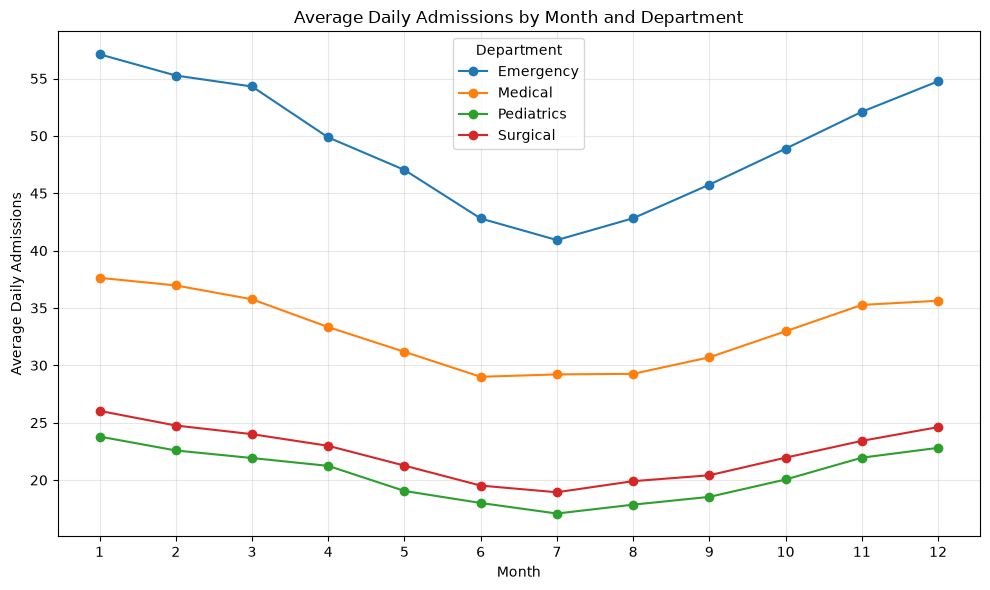

In [13]:
# Calculate monthly admissions for each department
department_monthly = (
    df.groupby(["month", "department"])["admissions"]
      .mean()
      .unstack()
)

print("Average monthly admissions by department:")
print(department_monthly.round(2))

# Plot
plt.figure(figsize=(10, 6))

for department in department_monthly.columns:
    plt.plot(
        department_monthly.index,
        department_monthly[department],
        marker="o",
        label=department
    )

plt.title("Average Daily Admissions by Month and Department")
plt.xlabel("Month")
plt.ylabel("Average Daily Admissions")
plt.xticks(range(1, 13))
plt.legend(title="Department")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Create daily hospital-level dataset for forecasting

daily_data = (
    df.groupby("date")
      .agg({
          "admissions": "sum",
          "discharges": "sum",
          "occupied_beds": "sum",
          "staff_count": "sum",
          "procedure_count": "sum"
      })
      .reset_index()
      .sort_values("date")
)

print("Forecasting dataset shape:", daily_data.shape)

print("\nFirst 5 rows:")
print(daily_data.head())

print("\nLast 5 rows:")
print(daily_data.tail())

Forecasting dataset shape: (731, 6)

First 5 rows:
        date  admissions  discharges  occupied_beds  staff_count  \
0 2024-01-01         148         122            231          131   
1 2024-01-02         139         133            223          137   
2 2024-01-03         152         124            237          134   
3 2024-01-04         136         129            238          138   
4 2024-01-05         145         130            241          138   

   procedure_count  
0               65  
1               67  
2               61  
3               61  
4               66  

Last 5 rows:
          date  admissions  discharges  occupied_beds  staff_count  \
726 2025-12-27         137         132            241          135   
727 2025-12-28         148         129            242          137   
728 2025-12-29         131         121            233          134   
729 2025-12-30         148         122            245          135   
730 2025-12-31         125         122            

In [15]:
# Create time-based features for forecasting

daily_data["day_of_week"] = daily_data["date"].dt.dayofweek
daily_data["month"] = daily_data["date"].dt.month
daily_data["day_of_year"] = daily_data["date"].dt.dayofyear

print("Dataset with time features:")
print(daily_data.head())

print("\nColumns:")
print(daily_data.columns.tolist())

Dataset with time features:
        date  admissions  discharges  occupied_beds  staff_count  \
0 2024-01-01         148         122            231          131   
1 2024-01-02         139         133            223          137   
2 2024-01-03         152         124            237          134   
3 2024-01-04         136         129            238          138   
4 2024-01-05         145         130            241          138   

   procedure_count  day_of_week  month  day_of_year  
0               65            0      1            1  
1               67            1      1            2  
2               61            2      1            3  
3               61            3      1            4  
4               66            4      1            5  

Columns:
['date', 'admissions', 'discharges', 'occupied_beds', 'staff_count', 'procedure_count', 'day_of_week', 'month', 'day_of_year']


In [16]:
# Create lag features for hospital admissions

daily_data["admissions_lag_1"] = daily_data["admissions"].shift(1)
daily_data["admissions_lag_7"] = daily_data["admissions"].shift(7)
daily_data["admissions_lag_14"] = daily_data["admissions"].shift(14)

print("Dataset with lag features:")
print(
    daily_data[
        [
            "date",
            "admissions",
            "admissions_lag_1",
            "admissions_lag_7",
            "admissions_lag_14"
        ]
    ].head(20)
)

Dataset with lag features:
         date  admissions  admissions_lag_1  admissions_lag_7  \
0  2024-01-01         148               NaN               NaN   
1  2024-01-02         139             148.0               NaN   
2  2024-01-03         152             139.0               NaN   
3  2024-01-04         136             152.0               NaN   
4  2024-01-05         145             136.0               NaN   
5  2024-01-06         137             145.0               NaN   
6  2024-01-07         152             137.0               NaN   
7  2024-01-08         156             152.0             148.0   
8  2024-01-09         146             156.0             139.0   
9  2024-01-10         149             146.0             152.0   
10 2024-01-11         154             149.0             136.0   
11 2024-01-12         150             154.0             145.0   
12 2024-01-13         157             150.0             137.0   
13 2024-01-14         123             157.0             152.0  

In [17]:
# Create rolling average features using past admissions

daily_data["admissions_rolling_7"] = (
    daily_data["admissions"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_data["admissions_rolling_14"] = (
    daily_data["admissions"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

print("Dataset with rolling average features:")

print(
    daily_data[
        [
            "date",
            "admissions",
            "admissions_rolling_7",
            "admissions_rolling_14"
        ]
    ].head(20)
)

Dataset with rolling average features:
         date  admissions  admissions_rolling_7  admissions_rolling_14
0  2024-01-01         148                   NaN                    NaN
1  2024-01-02         139                   NaN                    NaN
2  2024-01-03         152                   NaN                    NaN
3  2024-01-04         136                   NaN                    NaN
4  2024-01-05         145                   NaN                    NaN
5  2024-01-06         137                   NaN                    NaN
6  2024-01-07         152                   NaN                    NaN
7  2024-01-08         156            144.142857                    NaN
8  2024-01-09         146            145.285714                    NaN
9  2024-01-10         149            146.285714                    NaN
10 2024-01-11         154            145.857143                    NaN
11 2024-01-12         150            148.428571                    NaN
12 2024-01-13         157            1

In [18]:
# Create a clean dataset for machine learning

model_data = daily_data.dropna().copy()

print("Original dataset shape:", daily_data.shape)
print("Modeling dataset shape:", model_data.shape)

print("\nMissing values after cleaning:")
print(model_data.isnull().sum())

print("\nFirst 5 rows of modeling dataset:")
print(model_data.head())

Original dataset shape: (731, 14)
Modeling dataset shape: (717, 14)

Missing values after cleaning:
date                     0
admissions               0
discharges               0
occupied_beds            0
staff_count              0
procedure_count          0
day_of_week              0
month                    0
day_of_year              0
admissions_lag_1         0
admissions_lag_7         0
admissions_lag_14        0
admissions_rolling_7     0
admissions_rolling_14    0
dtype: int64

First 5 rows of modeling dataset:
         date  admissions  discharges  occupied_beds  staff_count  \
14 2024-01-15         142         134            249          138   
15 2024-01-16         142         131            244          139   
16 2024-01-17         154         128            254          141   
17 2024-01-18         140         133            253          135   
18 2024-01-19         146         138            252          132   

    procedure_count  day_of_week  month  day_of_year  admis

In [19]:
# Define features and target variable

feature_columns = [
    "day_of_week",
    "month",
    "day_of_year",
    "admissions_lag_1",
    "admissions_lag_7",
    "admissions_lag_14",
    "admissions_rolling_7",
    "admissions_rolling_14"
]

X = model_data[feature_columns]
y = model_data["admissions"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeatures used for forecasting:")
print(feature_columns)

print("\nFirst 5 rows of X:")
print(X.head())

print("\nFirst 5 target values:")
print(y.head())

Features (X) shape: (717, 8)
Target (y) shape: (717,)

Features used for forecasting:
['day_of_week', 'month', 'day_of_year', 'admissions_lag_1', 'admissions_lag_7', 'admissions_lag_14', 'admissions_rolling_7', 'admissions_rolling_14']

First 5 rows of X:
    day_of_week  month  day_of_year  admissions_lag_1  admissions_lag_7  \
14            0      1           15             123.0             156.0   
15            1      1           16             142.0             146.0   
16            2      1           17             142.0             149.0   
17            3      1           18             154.0             154.0   
18            4      1           19             140.0             150.0   

    admissions_lag_14  admissions_rolling_7  admissions_rolling_14  
14              148.0            147.857143             146.000000  
15              139.0            145.857143             145.571429  
16              152.0            145.285714             145.785714  
17              1

In [20]:
# Time-based train/test split
# First 80% = training data
# Last 20% = testing data

split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

train_dates = model_data["date"].iloc[:split_index]
test_dates = model_data["date"].iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_dates.iloc[0], "to", train_dates.iloc[-1])

print("\nTesting period:")
print(test_dates.iloc[0], "to", test_dates.iloc[-1])

Training samples: 573
Testing samples: 144

Training period:
2024-01-15 00:00:00 to 2025-08-09 00:00:00

Testing period:
2025-08-10 00:00:00 to 2025-12-31 00:00:00


In [21]:
# Create a simple baseline forecast
# Baseline assumption: today's admissions ≈ yesterday's admissions

baseline_predictions = X_test["admissions_lag_1"]

# Calculate baseline errors
baseline_mae = np.mean(np.abs(y_test - baseline_predictions))

baseline_rmse = np.sqrt(
    np.mean((y_test - baseline_predictions) ** 2)
)

print("Baseline Forecast Performance")
print("-----------------------------")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")

Baseline Forecast Performance
-----------------------------
MAE:  8.23
RMSE: 10.53


In [26]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 49.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
# Import Linear Regression and evaluation metrics

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)

# Evaluate the model
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MAE:  {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")

print("\nBaseline Performance")
print("--------------------")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")

Linear Regression Performance
-----------------------------
MAE:  6.16
RMSE: 7.59

Baseline Performance
--------------------
MAE:  8.23
RMSE: 10.53


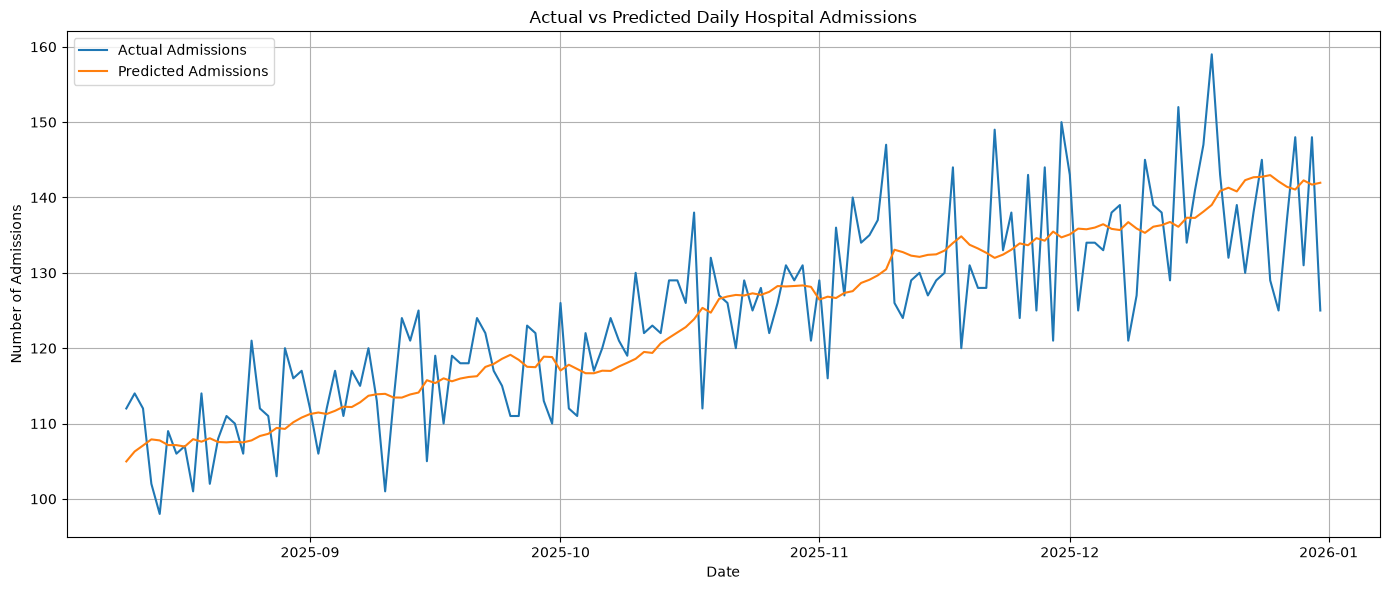

In [28]:
# Plot actual vs predicted hospital admissions

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Admissions"
)

plt.plot(
    test_dates,
    linear_predictions,
    label="Predicted Admissions"
)

plt.title("Actual vs Predicted Daily Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [29]:
# Build a Random Forest forecasting model

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

print("\nLinear Regression Performance")
print("-----------------------------")
print(f"MAE:  {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")

print("\nBaseline Performance")
print("--------------------")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")

Random Forest Performance
-------------------------
MAE:  6.10
RMSE: 7.49

Linear Regression Performance
-----------------------------
MAE:  6.16
RMSE: 7.59

Baseline Performance
--------------------
MAE:  8.23
RMSE: 10.53


Model Performance Comparison:
               Model   MAE   RMSE
0           Baseline  8.23  10.53
1  Linear Regression  6.16   7.59
2      Random Forest  6.10   7.49


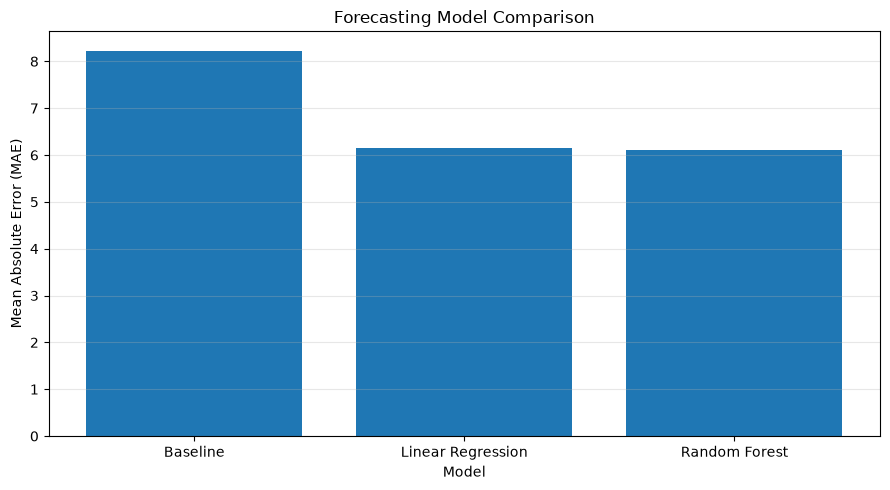

In [30]:
# Compare all forecasting models

model_names = [
    "Baseline",
    "Linear Regression",
    "Random Forest"
]

mae_scores = [
    baseline_mae,
    linear_mae,
    rf_mae
]

rmse_scores = [
    baseline_rmse,
    linear_rmse,
    rf_rmse
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "MAE": mae_scores,
    "RMSE": rmse_scores
})

print("Model Performance Comparison:")
print(comparison_df.round(2))

# Plot MAE comparison
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.title("Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

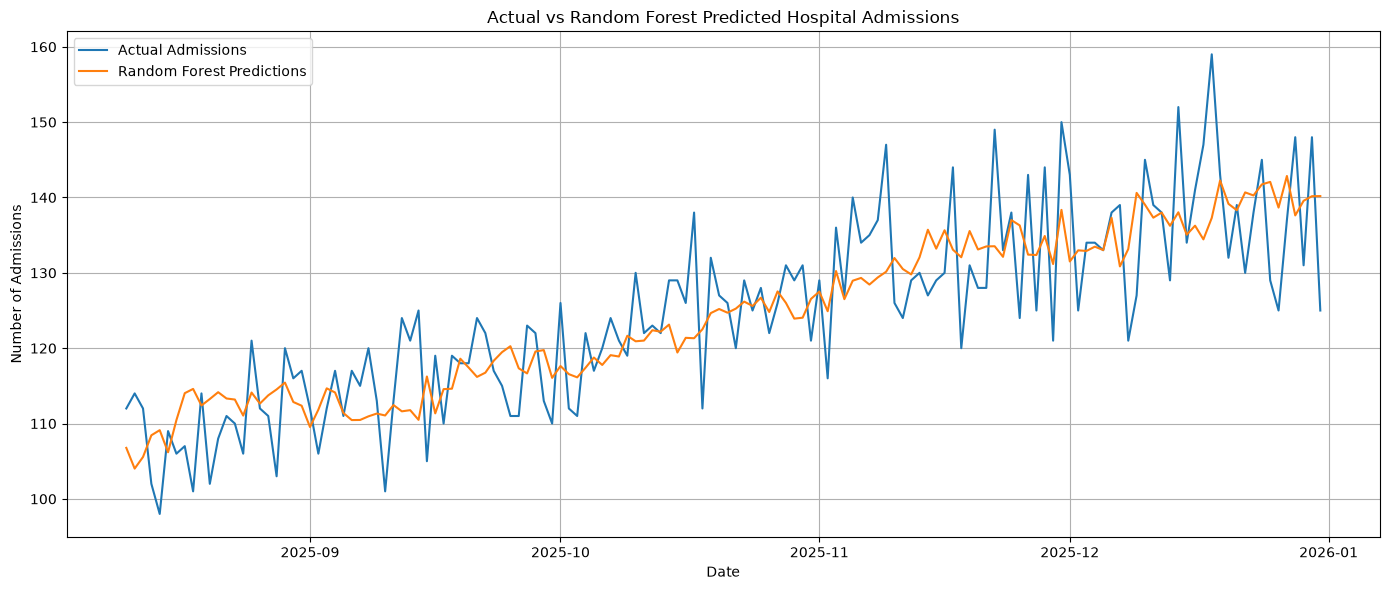

In [31]:
# Plot actual admissions vs Random Forest predictions

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Admissions"
)

plt.plot(
    test_dates,
    rf_predictions,
    label="Random Forest Predictions"
)

plt.title("Actual vs Random Forest Predicted Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Random Forest Feature Importance:
                 Feature  Importance
7  admissions_rolling_14    0.533307
6   admissions_rolling_7    0.301159
2            day_of_year    0.058283
3       admissions_lag_1    0.031735
5      admissions_lag_14    0.030190
4       admissions_lag_7    0.025760
0            day_of_week    0.017056
1                  month    0.002511


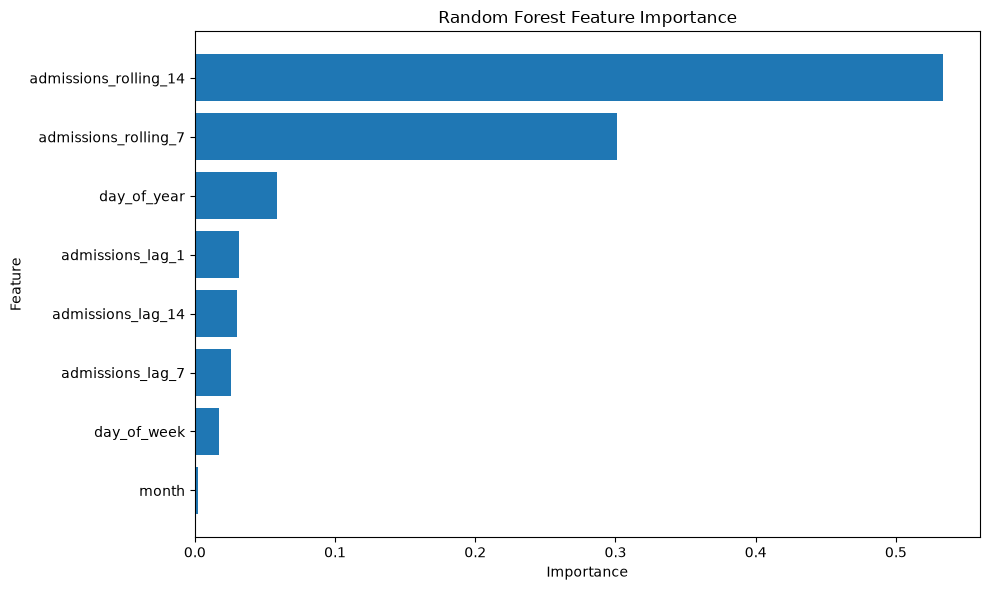

In [32]:
# Analyze Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [33]:
# Final project evaluation summary

mae_improvement = (
    (baseline_mae - rf_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rf_rmse) / baseline_rmse
) * 100

print("HOSPITAL ADMISSIONS FORECASTING - FINAL RESULTS")
print("=" * 52)

print(f"\nBaseline MAE:          {baseline_mae:.2f}")
print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Random Forest MAE:      {rf_mae:.2f}")

print(f"\nBaseline RMSE:          {baseline_rmse:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Random Forest RMSE:      {rf_rmse:.2f}")

print("\nRandom Forest Improvement Over Baseline:")
print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

print("\nSelected model: Random Forest")

HOSPITAL ADMISSIONS FORECASTING - FINAL RESULTS

Baseline MAE:          8.23
Linear Regression MAE: 6.16
Random Forest MAE:      6.10

Baseline RMSE:          10.53
Linear Regression RMSE: 7.59
Random Forest RMSE:      7.49

Random Forest Improvement Over Baseline:
MAE improvement:  25.88%
RMSE improvement: 28.86%

Selected model: Random Forest


In [34]:
# Save the trained model and evaluation results

import os
import joblib

# Create folders if they do not already exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Save Random Forest model
joblib.dump(
    random_forest_model,
    "../models/random_forest_admissions_model.pkl"
)

# Save model comparison results
comparison_df.to_csv(
    "../results/model_comparison.csv",
    index=False
)

# Save test predictions
predictions_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_admissions": y_test.values,
    "predicted_admissions": rf_predictions
})

predictions_df.to_csv(
    "../results/random_forest_predictions.csv",
    index=False
)

print("Model and results saved successfully.")
print("\nCreated files:")
print("models/random_forest_admissions_model.pkl")
print("results/model_comparison.csv")
print("results/random_forest_predictions.csv")

Model and results saved successfully.

Created files:
models/random_forest_admissions_model.pkl
results/model_comparison.csv
results/random_forest_predictions.csv


# Exploratory Data Analysis — Hospital Resource Demand Forecasting

This notebook explores the synthetic hospital operations dataset to understand demand patterns, resource utilization, seasonality, and department-level trends before developing forecasting models.

## Objectives

- Inspect and validate the dataset
- Analyze hospital admission and discharge patterns
- Examine bed occupancy and utilization
- Explore staffing and procedure volumes
- Identify temporal and seasonal patterns
- Compare demand across hospital departments
- Prepare insights for forecasting and feature engineering